# [LAB-07] 추론통계ㅣ2-가설검정의 이해(실습코드) yeonju

## #01. 준비작업 

### 1. 라이브러리 참조 

In [20]:
from jussam import load_data
from helpers import my_plot, my_stats
from pandas import melt, DataFrame

# 가설 검정의 가정에 필요한 패키지 
from scipy.stats import shapiro, skew, kurtosis, normaltest, bartlett, levene

### 2. 데이터 불러오기 

In [21]:
origin = load_data("two_store")
origin.head()

📚 동일한 제품을 판매하고 있는 서로 다른 두 지역의 매장의 100일간의 일별 매출액을 기록한 가상의 데이터 (출처: 방송통신대학교 통계학개론)


,store1,store2
0,34,63
1,63,85
2,57,75
3,50,48
4,37,58


## #02. 시각화를 통한 데이터 분포 확인 

### 1. 커널 밀도 그래프를 위한 데이터 재배치 

In [22]:
df = melt(origin, var_name="store", value_name="sales")
df.head()

,store,sales
0,store1,34
1,store1,63
2,store1,57
3,store1,50
4,store1,37


### 2. 데이터 분포 시각화 

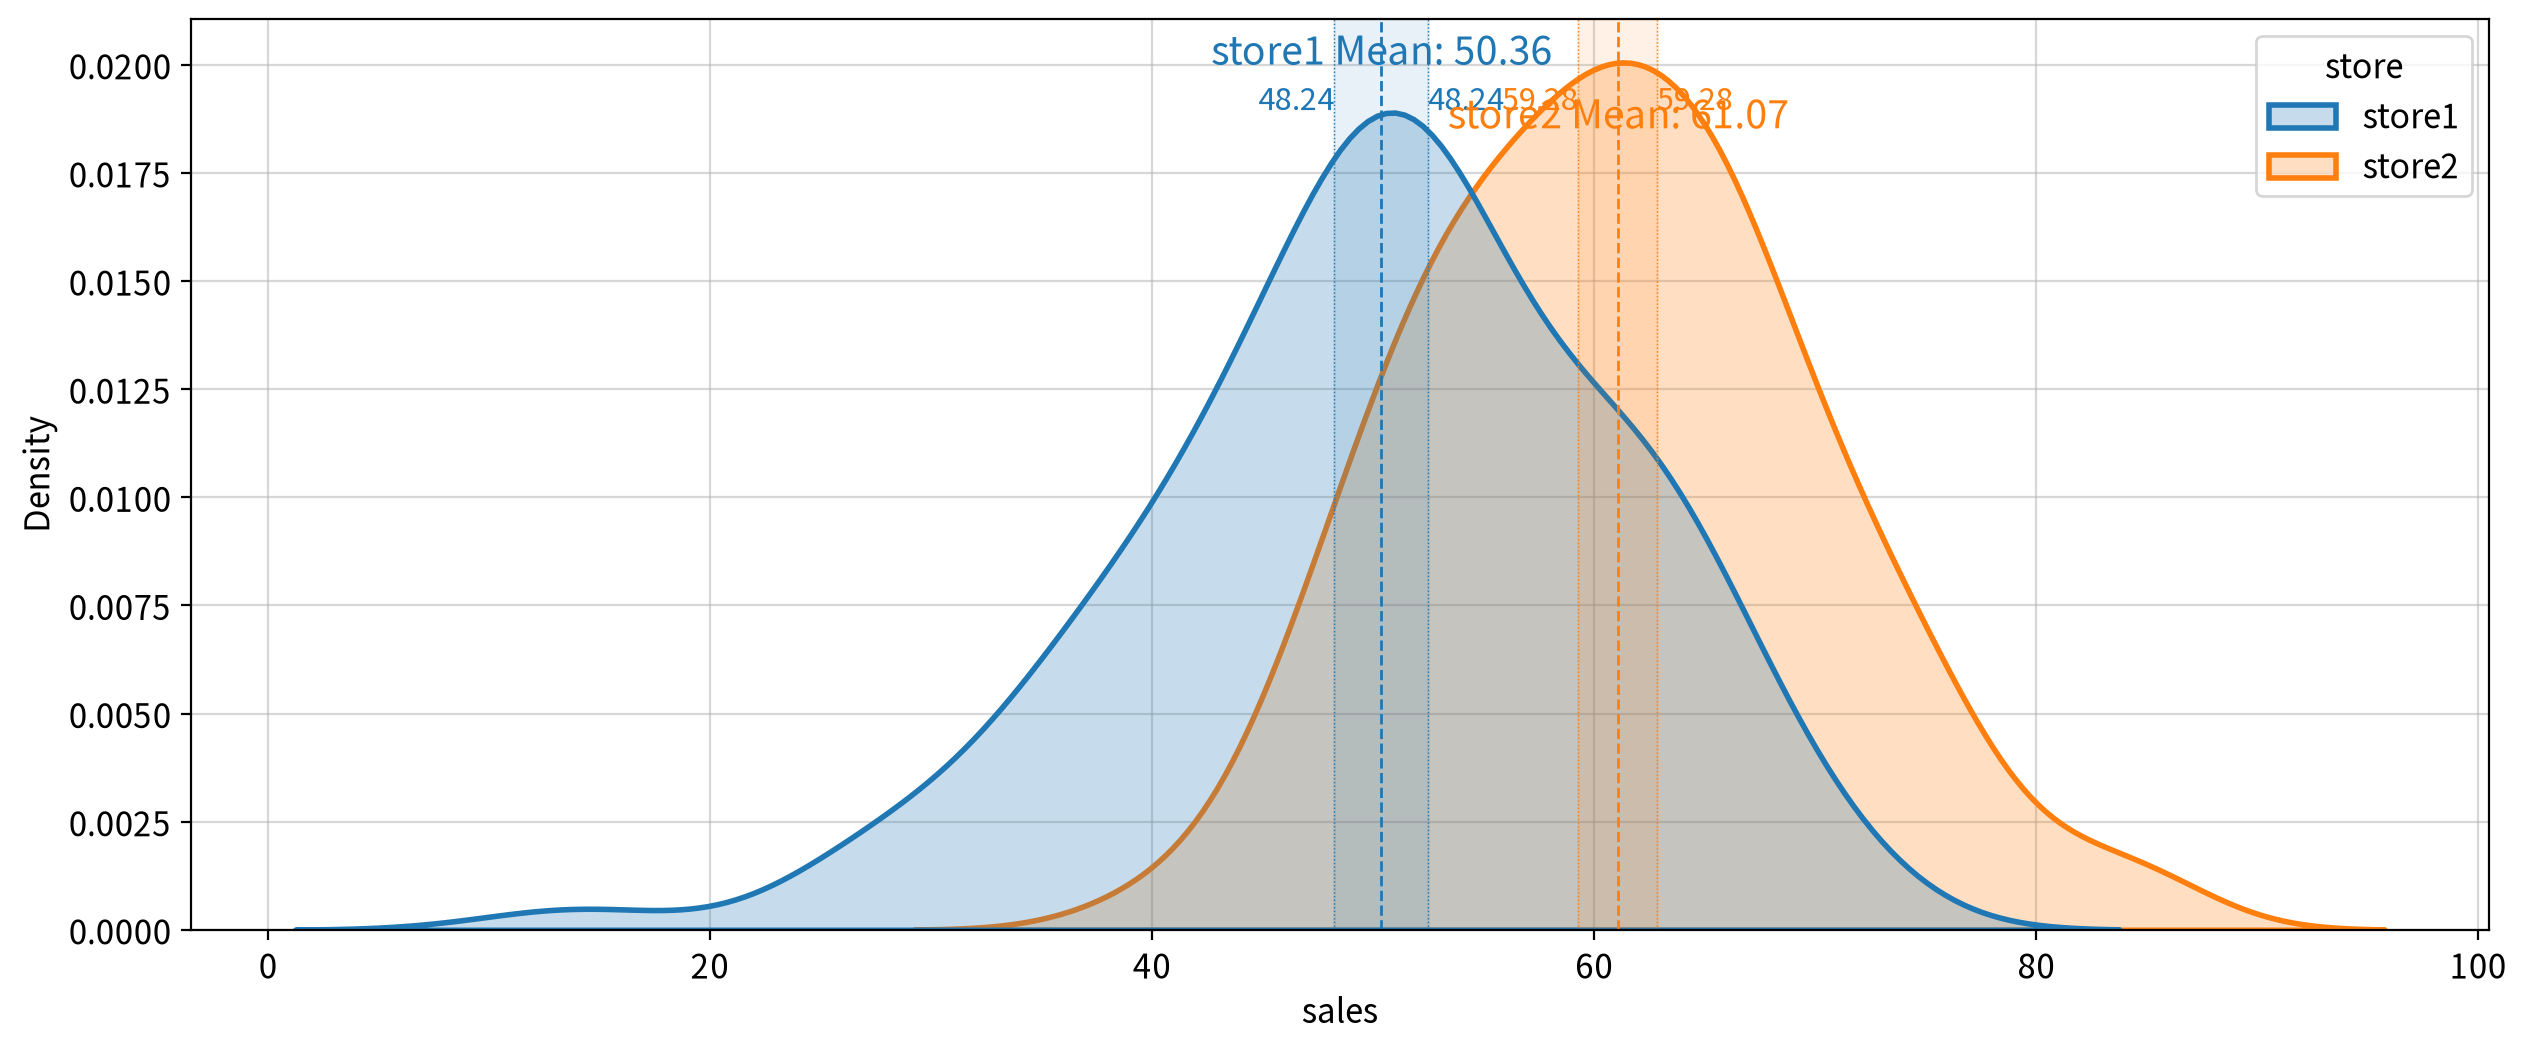

In [23]:
my_plot.kdeplot(df, x="sales", hue="store", 
                meanline=True,clevel=0.95, fill=True)

## #03. 통계량을 통한 데이터 정규성 확인 

### 1. Shapiro Wilk 검정 - store1에 대한 검정 

In [24]:
normal_tmpl = "statistic:{0:.3f}, p-value: {1:.3f}, 정규성 충족 여부: {2}"

In [25]:
s, p = shapiro(origin['store1'])
normal_tmpl.format(s, p, p >=0.05)  

'statistic:0.979, p-value: 0.109, 정규성 충족 여부: True'

### 2. Shapiro Wilk 검정 - store2에 대한 검정 

In [26]:
s, p = shapiro(origin['store2'])
normal_tmpl.format(s, p,p >=0.05)

'statistic:0.991, p-value: 0.731, 정규성 충족 여부: True'

### 3. Shapiro Wilk 검정 - store1에 대한 검정 

In [27]:
s, p = normaltest(origin['store1'])
normal_tmpl.format(s, p, p >=0.05)

'statistic:5.651, p-value: 0.059, 정규성 충족 여부: True'

### 4. Shapiro Wilk 검정 - store2에 대한 검정 

In [28]:
s, p = normaltest(origin['store2'])
normal_tmpl.format(s, p, p >=0.05)

'statistic:1.174, p-value: 0.556, 정규성 충족 여부: True'

## #04. 통계량을 통한 등분산성 확인 

### 1. Battlet 검정 

In [29]:
var_tmpl = "statistic: {0:.3f}, p-value: {1:.3f}, 등분산성 충족 여부: {2}"

In [30]:
s, p = bartlett(origin['store1'].astype('float'), 
               origin['store2'].astype('float'))

var_tmpl.format(s, p, p>=0.05)  

'statistic: 2.844, p-value: 0.092, 등분산성 충족 여부: True'

In [31]:
# 파라미터 수의 제한이 없다. 
s, p = levene(origin['store1'], origin['store2'], 
              center='median')
var_tmpl.format(s, p, p >=0.05)

'statistic: 1.360, p-value: 0.245, 등분산성 충족 여부: True'

## #04. 모듈화 기능 확인 

### 1. 가설 검정의 가정 일괄 확인 

In [32]:
# 정규성을 충족하는 데이터 -> Bartlett 검정이 선택됨 
# columns 인자를 지정하지 않으면 수치형 컬럼 전체에 대해 검정이 수행됨 
my_stats.test_assumptions(origin, columns=["store1", "store2"])

,test,statistic,p-value,result
field,,,,
store1,normaltest,5.651,0.059,True
store2,normaltest,1.174,0.556,True
Bartlett,equal_var,2.844,0.092,True


In [33]:
# 정규성을 충족하는 데이터 -> Bartlett 검정이 선택됨 
# columns 인자를 지정하지 않으면 수치형 컬럼 전체에 대해 검정이 수행됨 
# test_assumptions(origin, columns=["store1", "store2"])

In [34]:
# 네, 정확히 그거예요! 폴더 구조를 보니 원인이 명확하네요.
# my_stats.py는 helpers/ 폴더 안에 있어요. 근데 Cell 27에서는
# pythonfrom my_stats import test_assumptions
# 이렇게 최상위 모듈처럼 import를 시도했죠. Python이 my_stats라는 이름의 모듈을 찾을 때 sys.path에 등록된 경로들만 뒤지는데, helpers/는 하나의 패키지 폴더이지 sys.path에 직접 등록된 경로가 아니에요. 그래서 my_stats.py가 helpers/ 안에 있어도 Python 입장에서는 "그런 이름의 모듈 없음" 상태가 되는 거예요.
# (Cell 2에서 from helpers import my_plot, my_stats가 에러 없이 됐던 건, helpers라는 패키지 자체는 sys.path상 보이는 위치에 있고, 그 안의 서브모듈로 접근했기 때문이에요.)
# 해결 방법 (택 1)
# python# 방법 1: 패키지 경로로 import
# from helpers.my_stats import test_assumptions
# python# 방법 2: 모듈째로 가져와서 점(.) 찍어 호출
# from helpers import my_stats
# my_stats.test_assumptions(origin, columns=["store1", "store2"])
# 둘 다 잘 작동하지만, 이미 Cell 2에서 from helpers import my_plot, my_stats로 모듈을 가져와둔 상태이니, 방법 2가 더 자연스럽고 일관성 있어요. Cell 27은 아예 지우고 Cell 28을 my_stats.test_assumptions(...)로 바꾸시면 됩니다.

## #01. 연습문제 

In [35]:
### 1. 유의수준 0.03에서 
# 정규성 검정결과를 해석하고
# 기온과 판매량이 정규성 가정을 만족하는가 

In [36]:
origin = load_data('icecream')
origin

📚 기온과 아이스크림 판매량을 기록한 가상의 데이터 (메타데이터,인덱스 없음)


,기온,판매량
0,23,431
1,36,593
2,30,512
3,25,474
4,26,476
5,31,523
6,29,491
7,32,526
8,33,550
9,24,456


In [ ]:
from helpers import my_stats
my_stats.test_assumptions(origin, columns=["기온", "판매량"])

,test,statistic,p-value,result
field,,,,
기온,normaltest,2.745,0.253,True
판매량,normaltest,0.715,0.700,True
Bartlett,equal_var,44.148,0.000,False


## 문제 풀이

### 문제 1

유의수준 0.05에서 정규성 검정 결과를 해석하고, 기온과 판매량이 정규성 가정을 만족하는지 답하시오.

### 정답 및 해설

- **정답**: 두 변수 모두 정규성을 만족한다.
- **해설**: 정규성 검정의 귀무가설(H₀)은 "데이터가 정규분포를 따른다"이다. 기온(p=0.253)과 판매량(p=0.700) 모두 p-value가 0.05보다 크므로 귀무가설을 기각할 수 없다. 따라서 정규성 가정을 충족하며 result는 True이다.

### 문제 2

정규성 검정 결과에 따라 기온과 판매량의 등분산성을 검정하기 위해 사용되는 검정 방법은 무엇인가?

- **정답**: Barttlet 검정
- **해설**: 모든 변수가 정규성을 만족할 경우 Barttlet 검정을 사용하고 그렇지 않을 경우 Lavene 검정을 사용한다.

### 문제 3

두 변수가 등분산 가정을 만족하는지 판단하시오.

- **정답**: 등분산 가정을 만족하지 않는다
- **해설**: Bartlett 검정의 H₀는 "두 집단의 분산이 같다"이다. p-value가 0.000으로 0.05보다 작아 귀무가설을 기각하므로 분산이 서로 다르다고 본다. result는 False이다.